# Estruturas de Dados

## Arrays, Vetor, Vector ou List

- Estrutura de armazenamento e manipulação de dados mais simples.

- Na memória, um array ocupa um espaço contínuo de variáveis.

- Arrays possuem indices, ou seja, cada elemento pertence a uma posição específica, permitindo localizar e trocar elementos de posições.

- Em Python, Arrays tem o 1º elemento no indice 0.

- Python possui métodos como .append() e .pop() para facilitar a inserção/remoção do último elemento, assim como .insert() e .remove() para a inserção/remoção de elementos em posições aletórias.

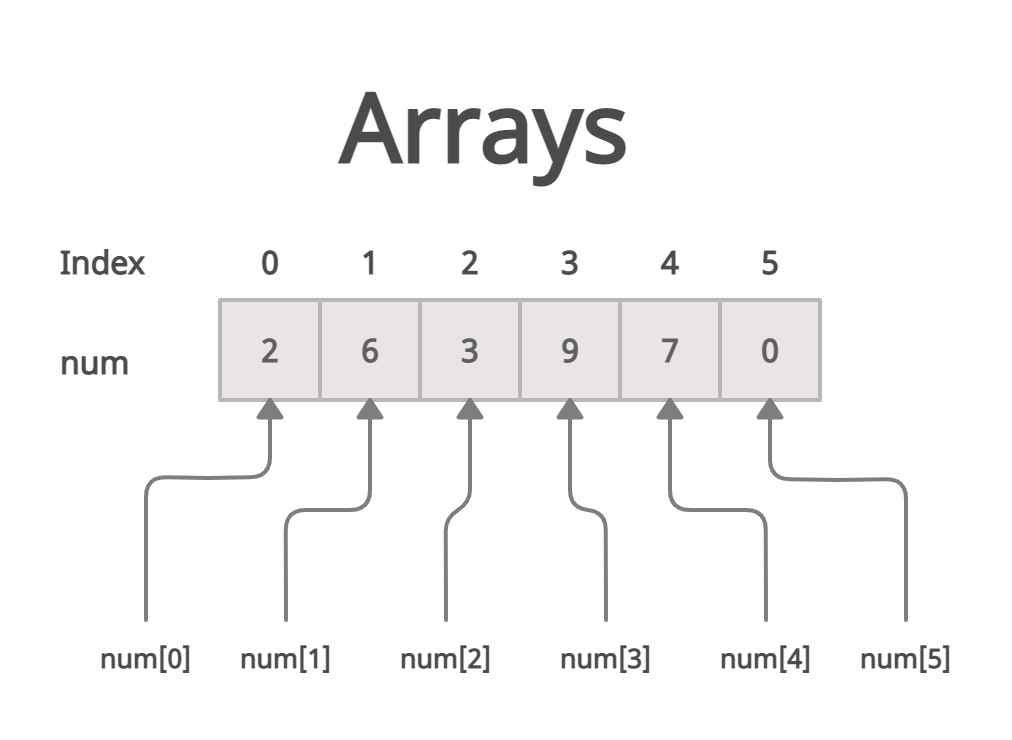

In [ ]:
array = [7, 12, 9, 4, 11]

def ler_valor():
    return int(input('Digite um valor numérico: '))

def buscar(arr, num):
    for i in range(len(arr)):
        if arr[i] == num:
            return f'Valor encontrado no índice {i}'
    return 'Valor não encontrado'

def inserir_ordenado(arr, num):
    arr.append(num)          # coloca no final
    i = len(arr) - 1
    while i > 0 and arr[i-1] > arr[i]:   # "borbulha" pra posição certa
        arr[i], arr[i-1] = arr[i-1], arr[i]
        i -= 1
    return 'Valor inserido!'

def remover(arr, num):
    for i in range(len(arr)):
        if arr[i] == num:
            for j in range(i, len(arr) - 1):
                arr[j] = arr[j+1]   # desloca tudo uma posição pra trás
            arr.pop()                # remove o último (duplicado)
            return 'Valor removido!'
    return 'Valor não encontrado'

while True:
    print('1 - INSERIR VALOR')
    print('2 - BUSCAR VALOR')
    print('3 - REMOVER VALOR')

    opcao = int(input('Digite a opção: '))

    match opcao:
        case 1:
            print(inserir_ordenado(array, ler_valor()))
        case 2:
            print(buscar(array, ler_valor()))
        case 3:
            print(remover(array, ler_valor()))
        case _:
            print('Opção inválida')

    print('Array atual:', array)

### Complexidade

- O tempo de execução do algoritmo é proporcional, ou linear, ao tamanho do conjunto de dados.

- Se um array possui 1000 valores, o loop teria que ser executado 1000 vezes.




| Operação | O que faz | Complexidade |
|---|---|---|
| acessar(i) | retorna o elemento na posição i | O(1) |
| atualizar(i, v) | substitui o valor na posição i | O(1) |
| inserir_fim(v) | insere no final (se houver espaço) | O(1)* |
| inserir(i, v) | insere na posição i | O(n) |
| remover(i) | remove o elemento da posição i | O(n) |
| buscar(v) | verifica se v existe (sem estar ordenado) | O(n) |

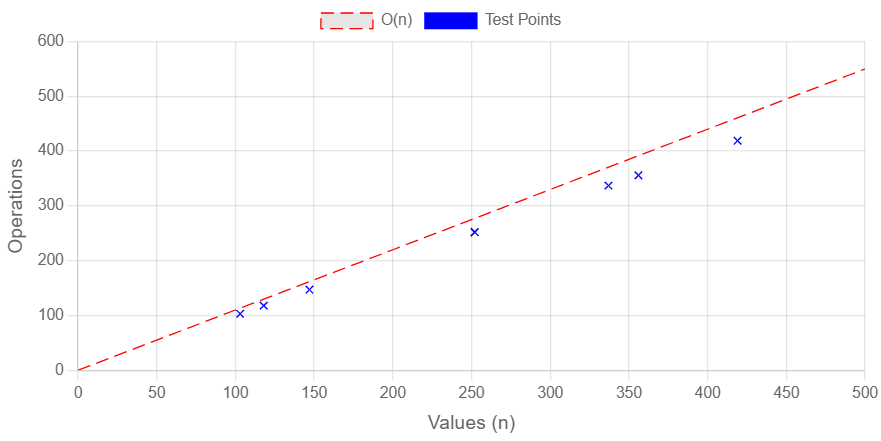

# Linked List (Listas Encadeadas)

- Estrutura de armazenamento e manipulação de dados construida a partir de Nodes e Ponteiros.

- Cada Node contêm um campo para 'Valor' e um ou dois campos para 'Ponteiros' a depender da aplicação.

- Cada Ponteiro pode apontar para o enderço de memória de outro Node, seja esse Node anterior ou próximo.

- Diferente da lista do Python (que é um array dinâmico), os elementos **não** ficam em posições contíguas de memória.

- Termos:

    - Head: Ponteiro que sempre apontará para o 1º elemento da lista.

    - Tail: Ponteiro que sempre apontará para o último elemento da lista.

#### Singly linked list (lista encadeada simples)                

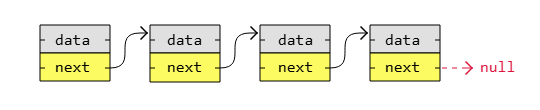

#### Doubly linked list (lista duplamente encadeada)

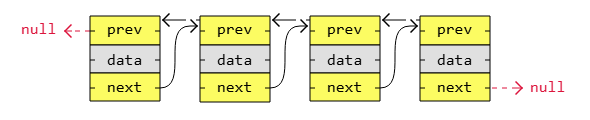

#### Circular linked list (lista circular (simples ou duplamente) encadeada)

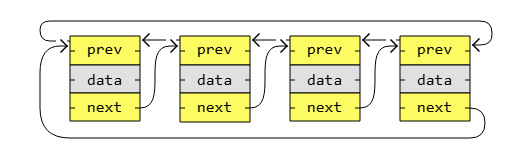

In [ ]:
class No:
    """Um nó individual da lista ligada:
    guarda um valor e aponta para o próximo nó."""

    def __init__(self, valor):
        self.valor = valor
        self.proximo = None  # por padrão, não aponta para lugar nenhum


class ListaLigada:
    """Lista ligada simples (singly linked list)."""

    def __init__(self):
        self.cabeca = None  # primeiro nó da lista (head)

    def inserir_inicio(self, valor):
        """Insere um novo nó no início da lista. O(1)"""
        novo_no = No(valor)
        novo_no.proximo = self.cabeca
        self.cabeca = novo_no

    def inserir_fim(self, valor):
        """Insere um novo nó no final da lista. O(n)"""
        novo_no = No(valor)
        if self.cabeca is None:
            self.cabeca = novo_no
            return
        atual = self.cabeca
        while atual.proximo is not None:
            atual = atual.proximo
        atual.proximo = novo_no

    def remover(self, valor):
        """Remove a primeira ocorrência do valor. Retorna True se removeu, False se não achou. O(n)"""
        atual = self.cabeca
        anterior = None

        while atual is not None:
            if atual.valor == valor:
                if anterior is None:       # o nó a remover é a cabeça
                    self.cabeca = atual.proximo
                else:
                    anterior.proximo = atual.proximo
                return True
            anterior = atual
            atual = atual.proximo

        return False  # valor não encontrado

    def buscar(self, valor):
        """Retorna True se o valor existir na lista. O(n)"""
        atual = self.cabeca
        while atual is not None:
            if atual.valor == valor:
                return True
            atual = atual.proximo
        return False

    def __repr__(self):
        valores = []
        atual = self.cabeca
        while atual is not None:
            valores.append(str(atual.valor))
            atual = atual.proximo
        return " -> ".join(valores) + " -> None"


# --- Demonstração ---
lista = ListaLigada()
lista.inserir_fim(10)
lista.inserir_fim(20)
lista.inserir_fim(30)
lista.inserir_inicio(5)
print(lista)                     # 5 -> 10 -> 20 -> 30 -> None

lista.remover(20)
print(lista)                     # 5 -> 10 -> 30 -> None

print("Contém 10?", lista.buscar(10))  # True
print("Contém 99?", lista.buscar(99))  # False

### Complexidade

- São muito boas para alocação dinâmica (inserção em posições aleatórias) e alterações nas extremidades.

- Sua complexidade pode ser reduzida quando implementamos ponteiros como *HEAD* e *TAIL*.

- Perdem para Arrays quando se trata de buscar, inserir ou remover valores em posições "aleatórias".

**Operações principais:**
| Operação | O que faz | Complexidade |
|---|---|---|
| `inserir_inicio(v)` | insere no começo | O(1) |
| `inserir_fim(v)` | insere no final | O(n)* |
| `remover(v)` | remove o primeiro nó com valor v | O(n) |
| `buscar(v)` | verifica se v existe | O(n) |
| `imprimir()` | percorre e mostra todos os nós | O(n) |

# Queue (Fila)

- Estrutura que usa o conceito de `FIFO` (First In, First Out - O primeiro a entrar é o primeiro a sair).

- Pode ser implementada usando Arrays ou Linked Lists

- Termos: 
    - Enqueue (Inserção)
    - Dequeue (Remoção)
    - Peek (Retorna o próximo elemento a sair)
    - isEmpty (Verifica se a Fila está vazia)
    - Size (números de elementos da Fila)